# Marker free FLM-TEM correlation using the reflective boundary visible in both modalities

![Pipeline](./Picture1.png)

In [8]:
from roi_detect.models import *
from roi_detect.roi import *
from roi_detect.viz import *

In [9]:
from pathlib import Path
from skimage import io
import ipywidgets as widgets
from matplotlib.gridspec import GridSpec
from lightglue import viz2d # type: ignore

In [10]:
ROOT_DIR = Path.cwd().parent # root directory
DEFAULT_DIR = ROOT_DIR / "jey_002_g3_l8"
flm_path =  DEFAULT_DIR / "Composite-stacks-JEY002-G3-L8.tif"
tem_path = DEFAULT_DIR / "JEY002_G3_L8_1950x_t-13.tif"
flm_pixel_nm = 121.0
tem_pixel_nm = 6.9
pad_factor = 1

In [11]:
flm_stack = io.imread(str(flm_path))
tem_img = io.imread(str(tem_path))
tem_h, tem_w = tem_img.shape[:2]
tem_height_flm = (tem_h * tem_pixel_nm) / flm_pixel_nm
tem_width_flm  = (tem_w * tem_pixel_nm) / flm_pixel_nm
flm_h, flm_w = flm_stack.shape[1:3]
# convert uint16 to unint 8
rendered_stack = render_all_frames(flm_stack, render_flm_frame)

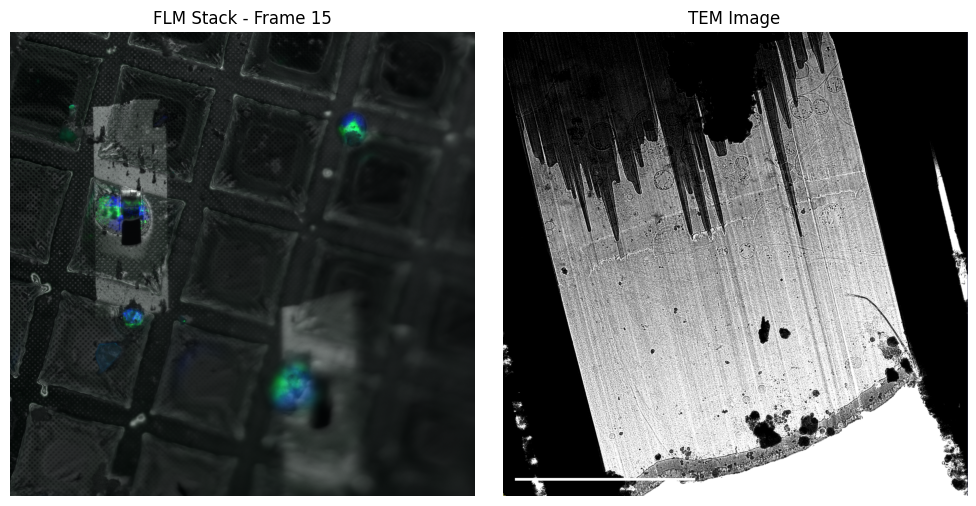

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rendered_stack[15])
axes[0].set_title('FLM Stack - Frame 15')
axes[0].axis('off')
axes[1].imshow(tem_img)
axes[1].set_title('TEM Image')
axes[1].axis('off')
plt.tight_layout()

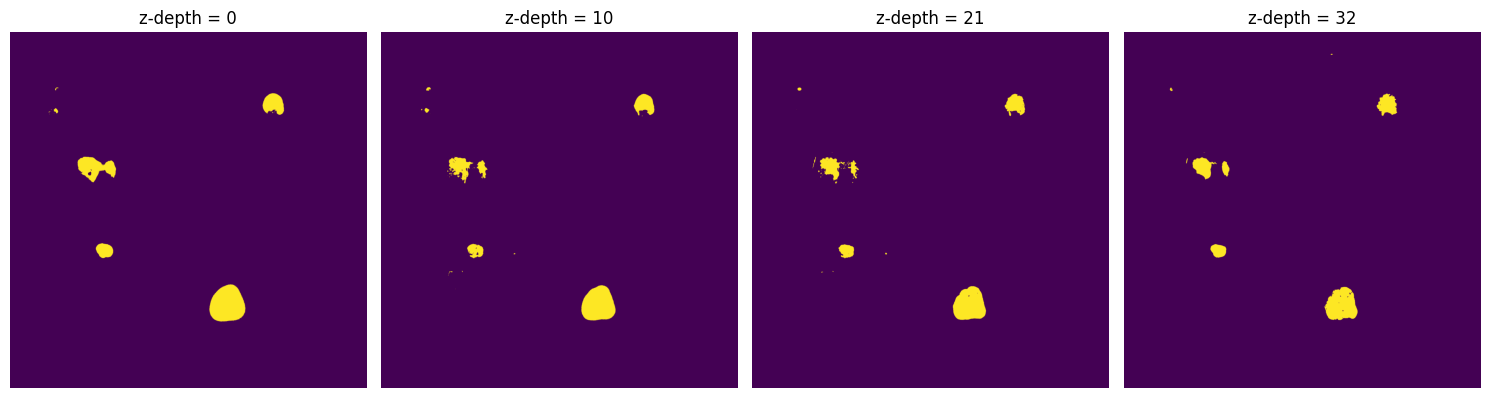

In [12]:
# show the ROI masks that are found by using Otsu thresholding for a few frames to demonstrate what has been found and that the problem are
n = len(flm_stack)
indices = np.linspace(0, n-1, 4, dtype=int)  # 4 evenly spaced indices including ends

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, i in zip(axes, indices):
    roi_mask = get_roi_mask(flm_stack[i])
    ax.imshow(roi_mask)
    ax.set_title(f'z-depth = {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# showing example for 15th frame
frame_idx = 15
img_flm = flm_stack[frame_idx]
roi_mask = get_roi_mask(img_flm)
bboxes = get_bbox_from_roi_mask(roi_mask)

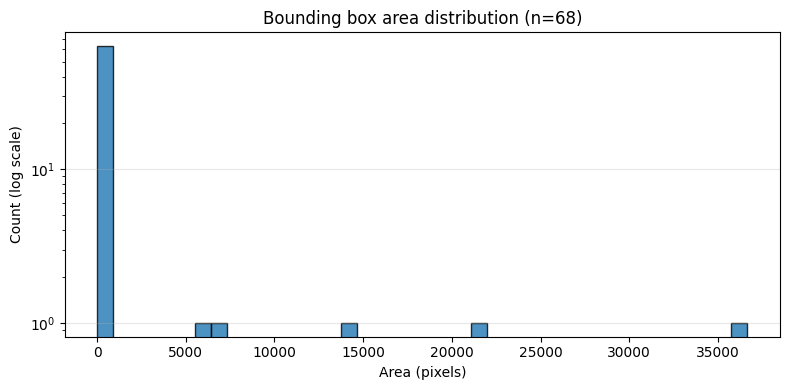

array([  432, 14364,   575,     1,    12,     6,     6, 21114,     6,
           4,     1,  6180,     1,     1,    16,    48,     4,     2,
           9,    12,    16,    18,    16,    28,     2,     2,     4,
           1,     1,    12,    20,    80,     2,     2,    72,    48,
           2,     1,    20,     2,    35,    20,    90,   144,    30,
           9,    36,     1,    20,     1,     9,     9,     1,    25,
           1,     9,  7128,     1,    70,     2,     1,    99,   225,
           1,     1, 36666,     1,     1])

In [14]:
# showing that most of the areas are very small and not needed
plot_bbox_area_hist(bboxes, bins=40, log_scale=True)

In [15]:
# select a bbox to display the scatter of bounding boxes properly
target_idx = 29

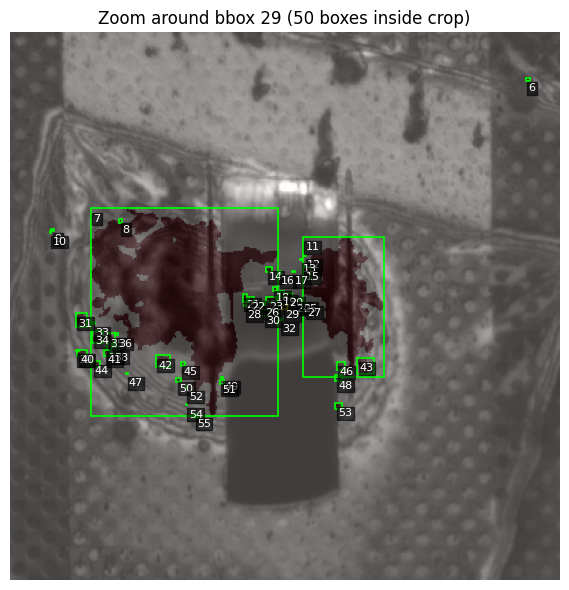

In [16]:
# this show the boxes up close to see that there are a lot of them that are really small 
# these boxes need to be filter out as they are noise
# this specific example also show the need for bigger bounding boxes witing tem_height_flm range to be merged
show_zoom(img_flm, roi_mask, bboxes, target_idx=target_idx, pad=200)

In [17]:
filted_and_merged_bboxes = filter_and_merge_bboxes(bboxes, tem_height_flm / 2, tem_width_flm / 2, flm_h, flm_w)

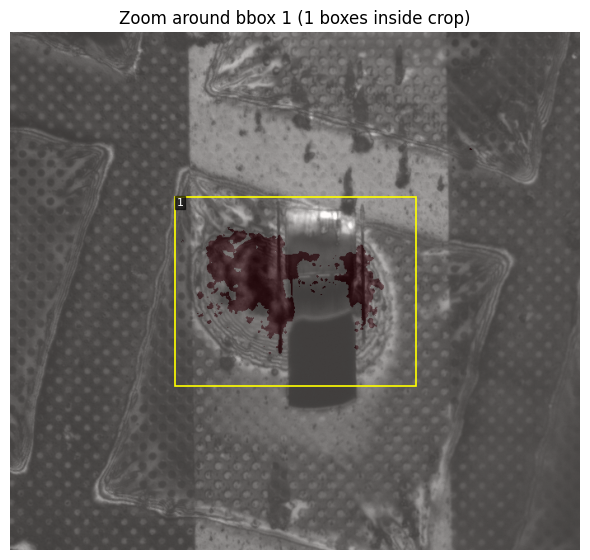

In [18]:
target_idx = 1
show_zoom(img_flm, roi_mask, filted_and_merged_bboxes, target_idx=target_idx, pad=200)

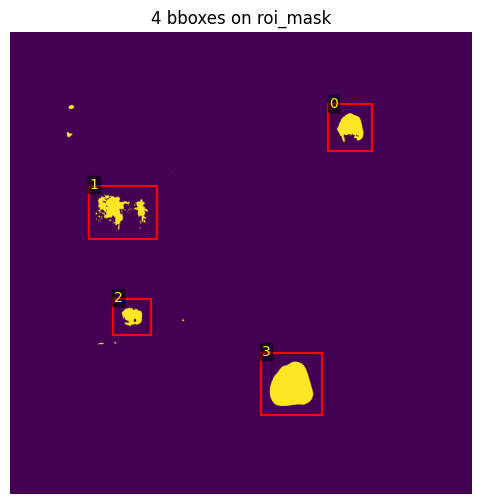

In [19]:
plot_bbox_over_roi_mask(roi_mask, filted_and_merged_bboxes)

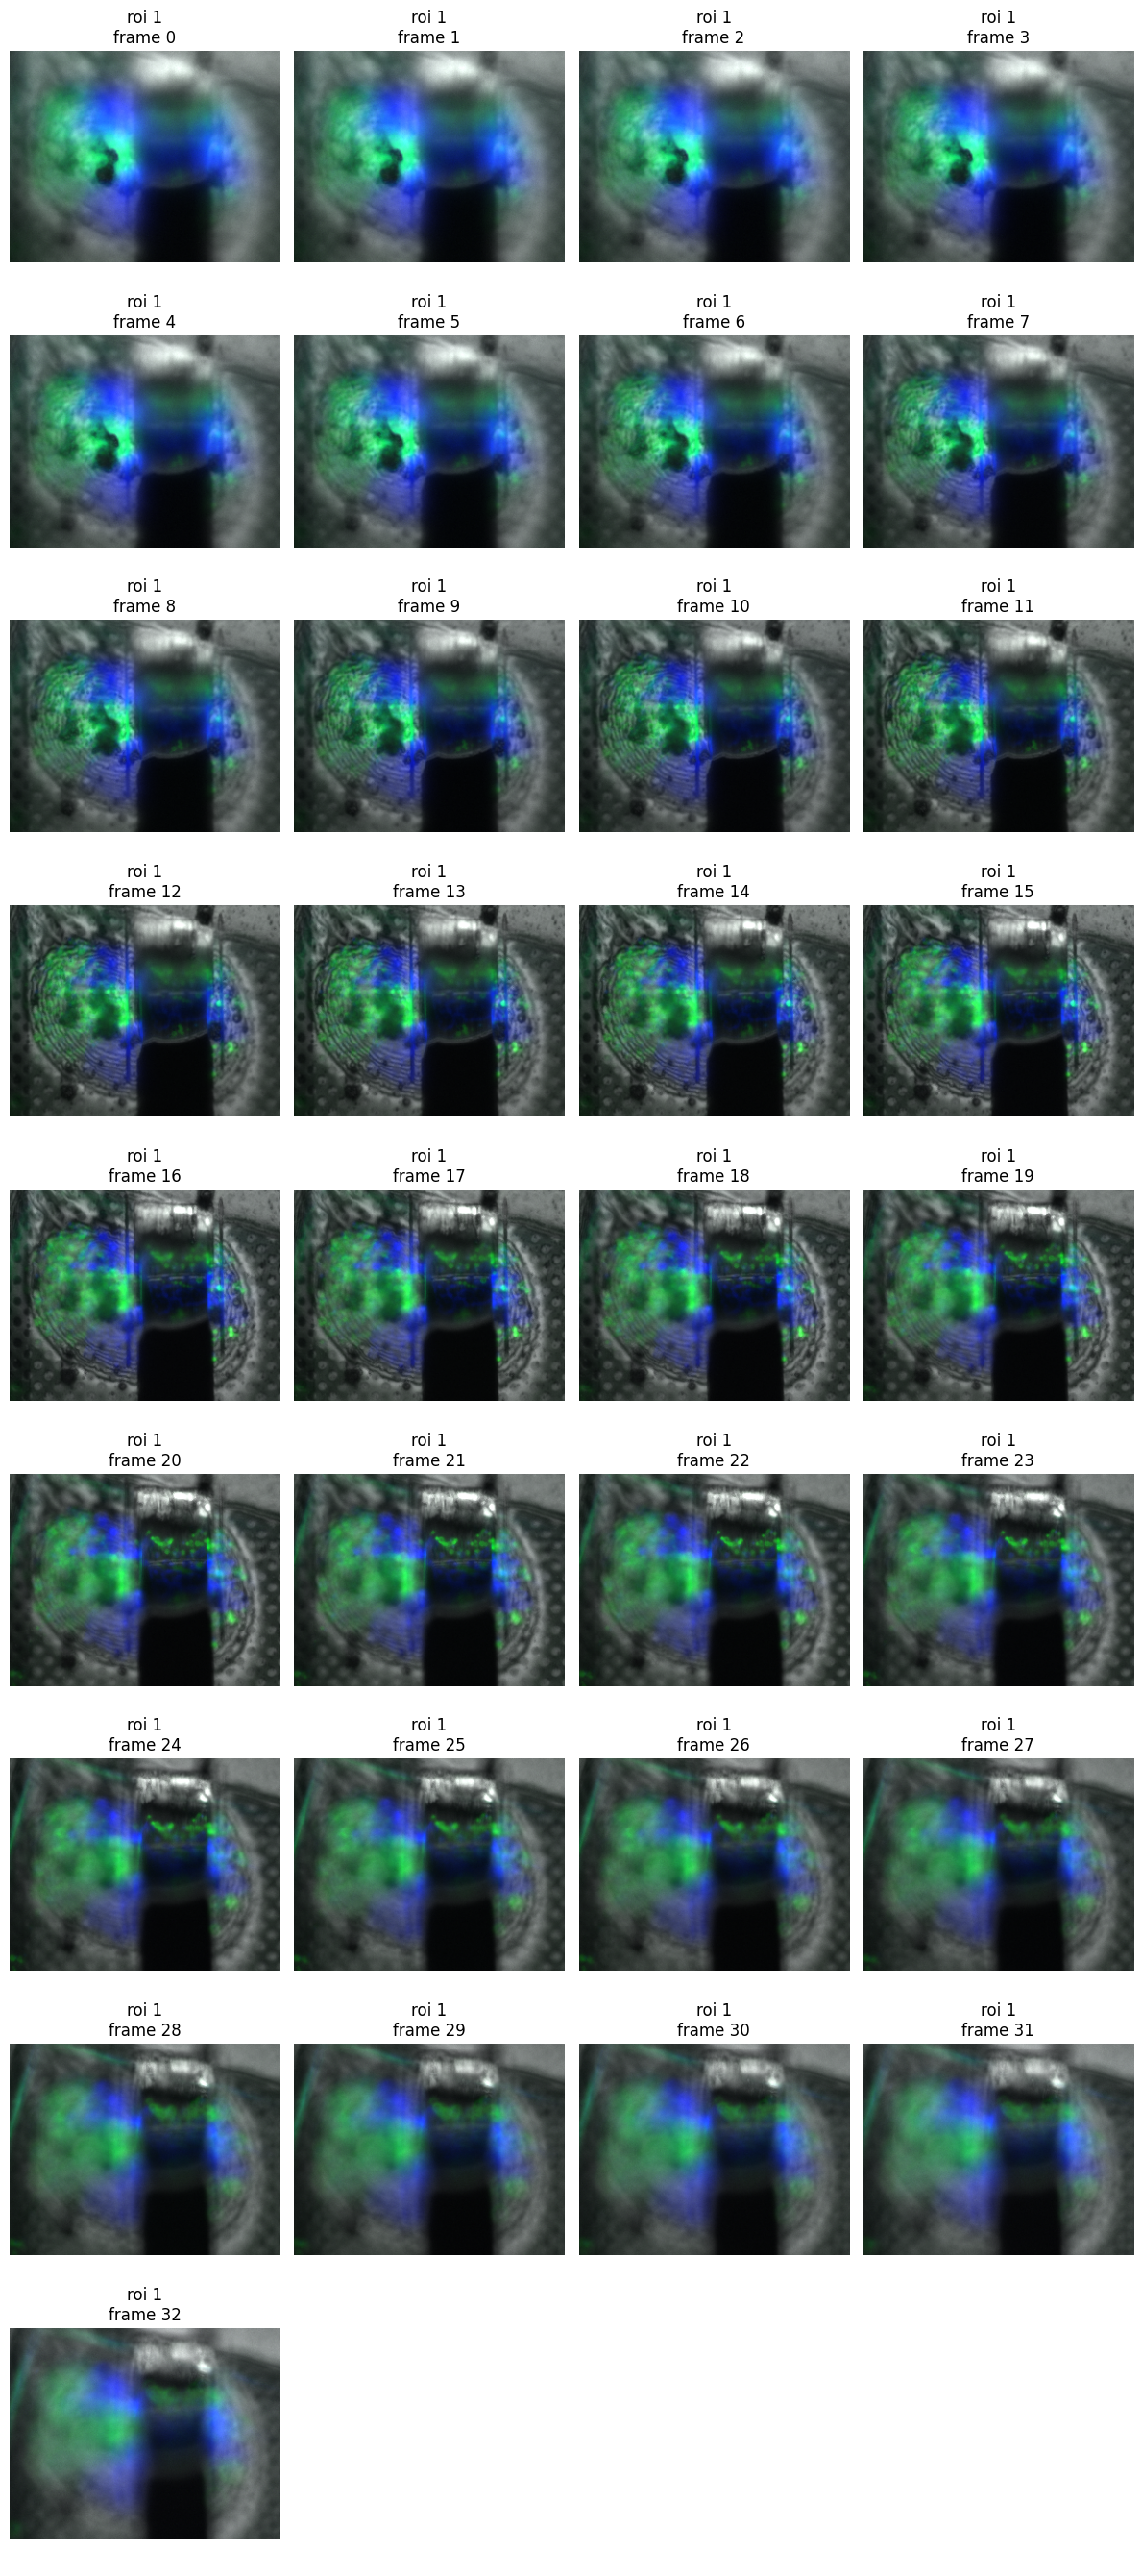

In [20]:
# crop across the stack using these bounding boxes
# crops: list of tuples (roi_idx, frame_idx, crop_array)
roi_idx = 1
bbox = filted_and_merged_bboxes[roi_idx]
rendered_stack = np.array(rendered_stack)
crops = []
for i in range(len(rendered_stack)):
    y0, x0, y1, x1 = bbox
    crops.append((roi_idx, i, rendered_stack[i, y0:y1, x0:x1]))
plot_group_crops(crops)

In [21]:
# next step is to figure out the best z section based on Laplacian
laps_per_bbox = get_laplacian_per_bbox(flm_stack, filted_and_merged_bboxes)

In [22]:
len(laps_per_bbox)

4

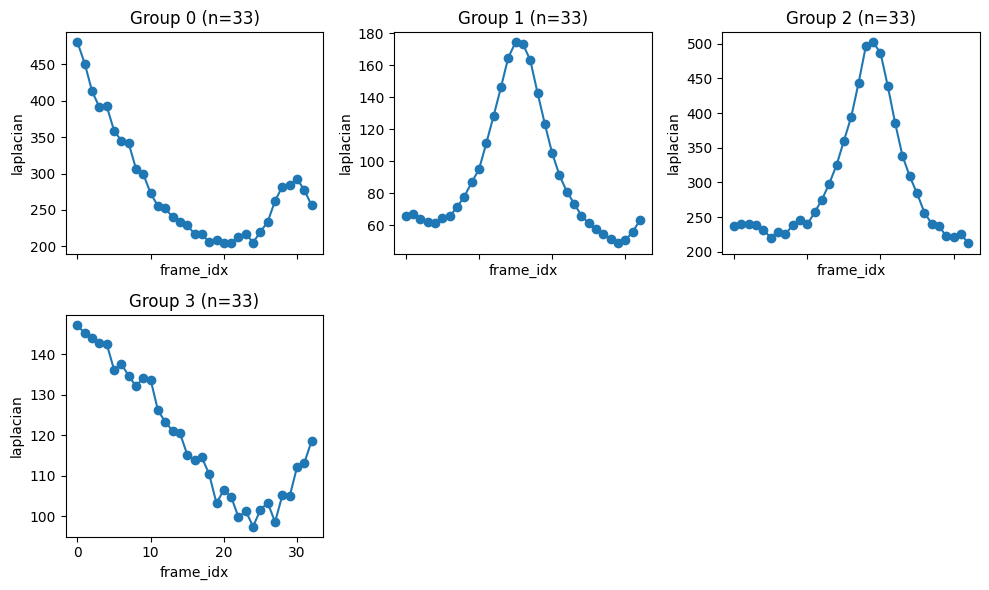

In [23]:
# plot of laplacian across the frames for different groups/bboxes
plot_groups_laplacian(groups_vals=laps_per_bbox)

In [24]:
for bbox_idx, laps in enumerate(laps_per_bbox):
    peak_idx, peak_vals = find_flat_peak(laps)
    if peak_idx:
        print(f"BBox: {bbox_idx} -> Best Frame: {peak_idx}, Val: {peak_vals[peak_idx]}")
    else:
        print(f"BBox: {bbox_idx} -> No peak found")


BBox: 0 -> No peak found
BBox: 1 -> Best Frame: 15, Val: 157.85741779026267
BBox: 2 -> Best Frame: 19, Val: 456.5299675828395
BBox: 3 -> No peak found


In [25]:
# select the best frame and the region containing the TEM structure for further processing
# show the enhanced contrast image
best_bbox_idx = 1
best_frame_idx = 15

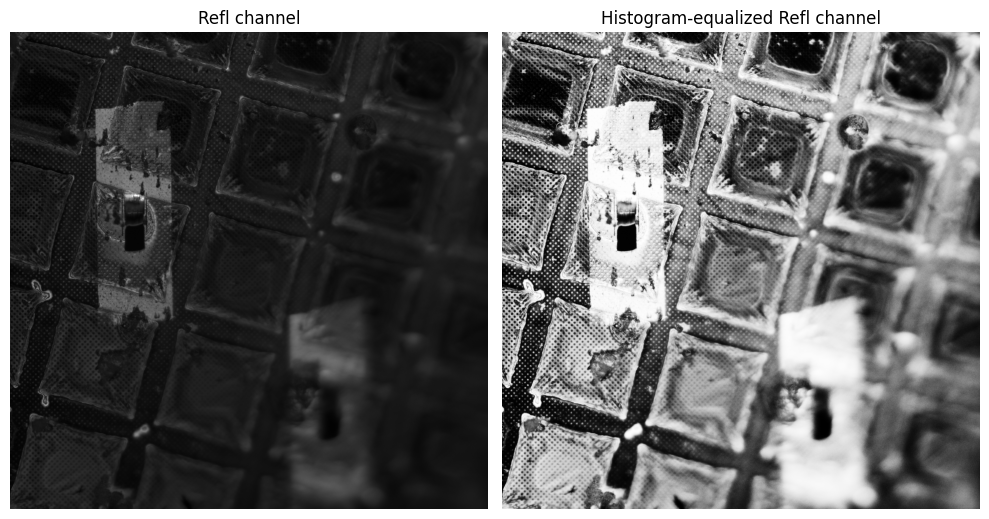

In [26]:
flm_frame = flm_stack[best_frame_idx, :, :, 1] # use refl channel
flm_refl_uint8 = norm(flm_frame)
flm_img_hist_eq = exposure.equalize_hist(flm_refl_uint8)
flm_img_hist_eq = (flm_img_hist_eq * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].imshow(flm_refl_uint8, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Refl channel')
axes[0].axis('off')

axes[1].imshow(flm_img_hist_eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Histogram-equalized Refl channel')
axes[1].axis('off')

plt.tight_layout()
plt.show()

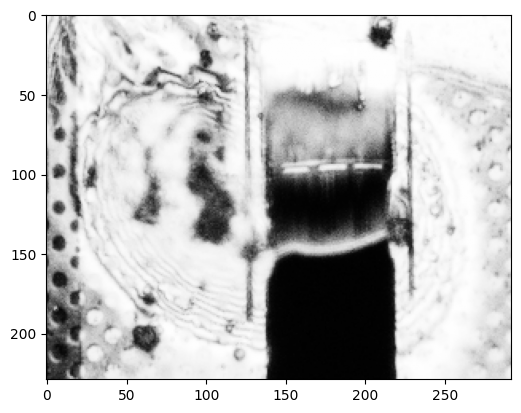

In [27]:
best_bbox_pts = filted_and_merged_bboxes[best_bbox_idx]
bb_y0, bb_x0, bb_y1, bb_x1 = best_bbox_pts
best_roi_cropped = flm_img_hist_eq[bb_y0:bb_y1, bb_x0:bb_x1]
plt.figure(figsize=(6, 6))
plt.imshow(best_roi_cropped, cmap='gray');

In [28]:
# conver the cropped img which is grey scale into RGB for processing
best_roi_cropped_rgb = np.stack([best_roi_cropped] * 3, axis=-1)
print(f"Channels in RGB crop: {best_roi_cropped_rgb.shape[-1]}")

Channels in RGB crop: 3


In [29]:
# next step is cropping the image with overlapping bounding boxes
flm_w = bb_x1 - bb_x0
flm_h = bb_y1 - bb_y0
tiles_bbox, padding = get_tile_flm_bbox_with_pad(
    flm_height=flm_h, flm_width=flm_w, 
    tem_height=tem_h, tem_width=tem_w,
    flm_pixel_nm=flm_pixel_nm, 
    tem_pixel_nm=tem_pixel_nm,
    tile_scale=1.5
)

pad_top, pad_bottom, pad_left, pad_right = padding
padded = np.pad(best_roi_cropped_rgb, ((pad_top, pad_bottom), (pad_left, pad_right), (0,0)), mode='constant', constant_values=0)

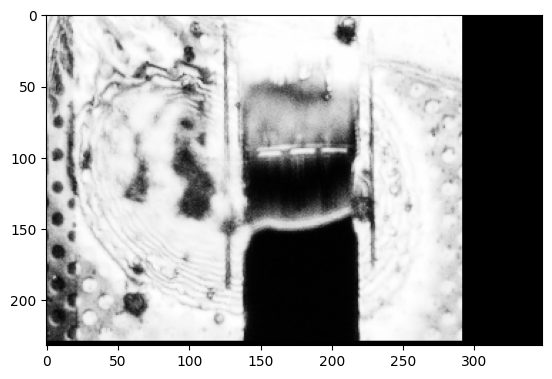

In [30]:
plt.imshow(padded)

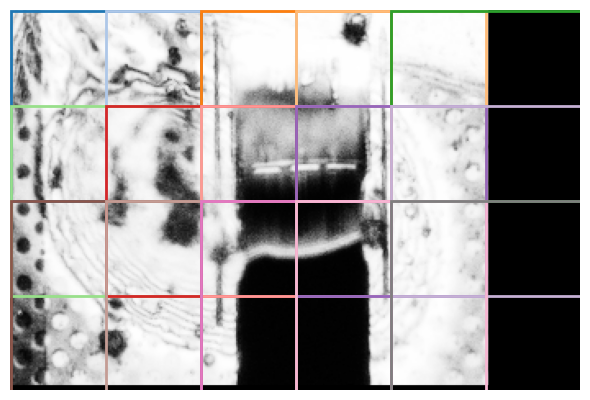

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(padded)

# color cycle from a qualitative colormap
cmap = plt.get_cmap('tab20')
n = len(tiles_bbox)
for idx, (y0, x0, y1, x1) in enumerate(tiles_bbox):
    h = y1 - y0
    w = x1 - x0
    color = cmap(idx % cmap.N)
    rect = patches.Rectangle((x0, y0), w, h, edgecolor=color, facecolor='none', linewidth=2)
    ax.add_patch(rect)

ax.set_axis_off()
plt.tight_layout()
plt.show()

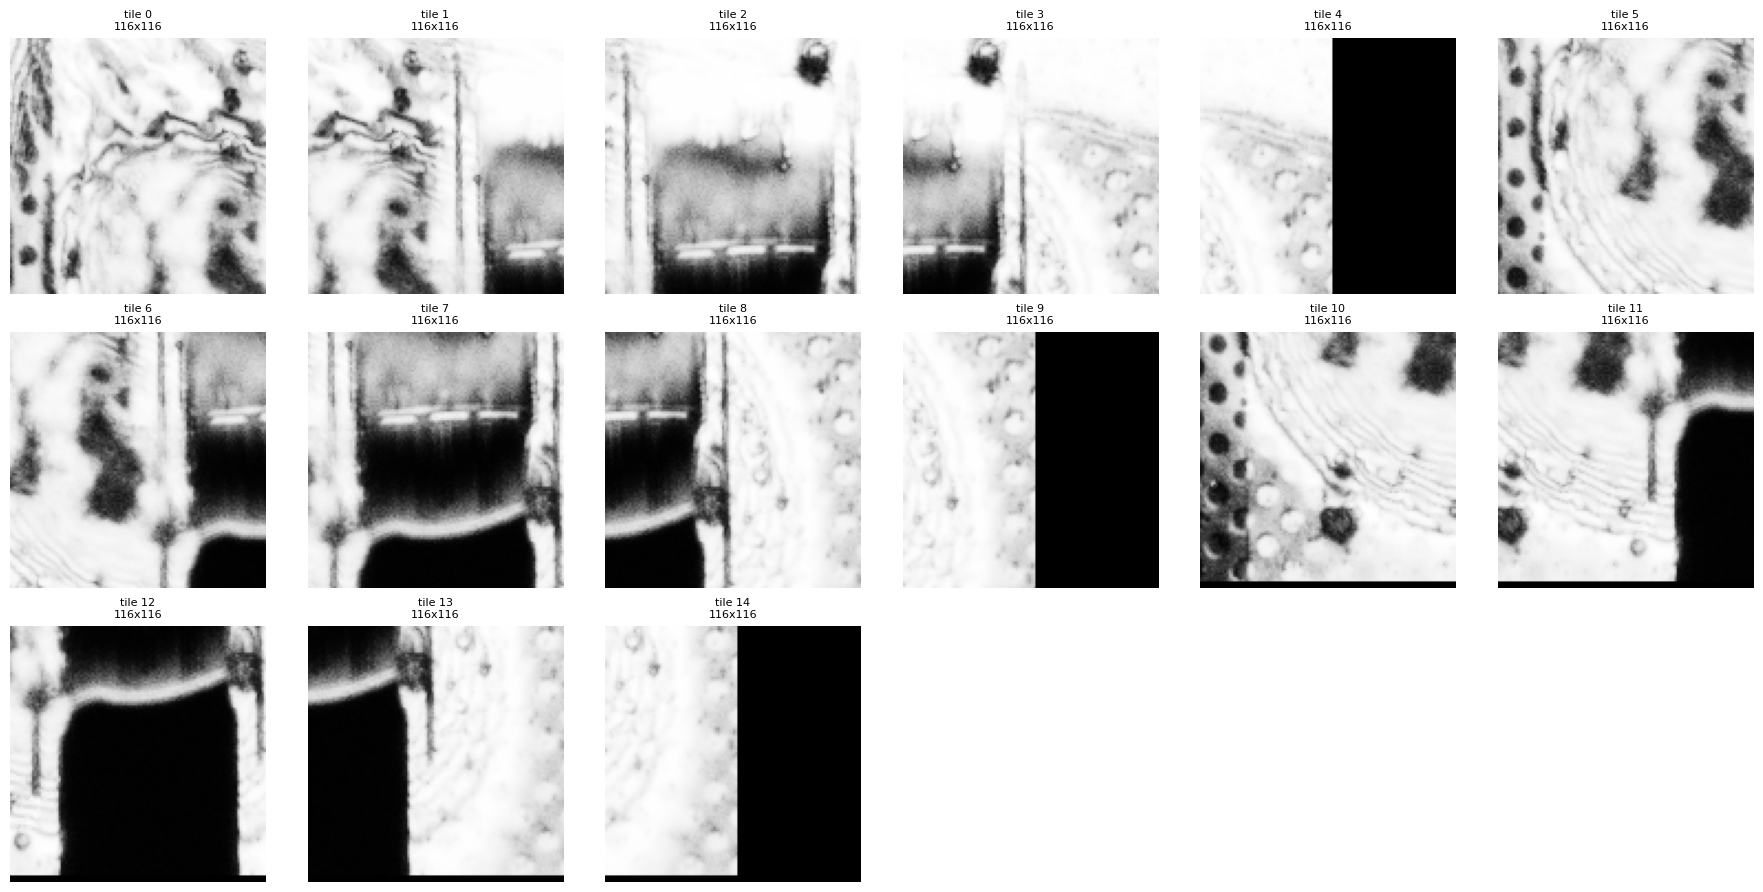

In [32]:
def show_tiles_grid(padded, tiles, cols=None, thumb_size=(2,2), cmap=None):
    n = len(tiles)
    if n == 0:
        return

    if cols is None:
        cols = min(6, int(math.ceil(math.sqrt(n))))  # reasonable default
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * thumb_size[0], rows * thumb_size[1]),
                             squeeze=False)
    axes = axes.flatten()

    for ax in axes:
        ax.axis('off')

    for i, (y0, x0, y1, x1) in enumerate(tiles):
        crop = padded[y0:y1, x0:x1]
        ax = axes[i]
        ax.imshow(crop, cmap=cmap)
        ax.set_title(f'tile {i}\n{crop.shape[0]}x{crop.shape[1]}', fontsize=8)
        ax.axis('off')

    # hide any remaining axes
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

show_tiles_grid(padded, tiles_bbox, cols=6, thumb_size=(3, 3), cmap=None)

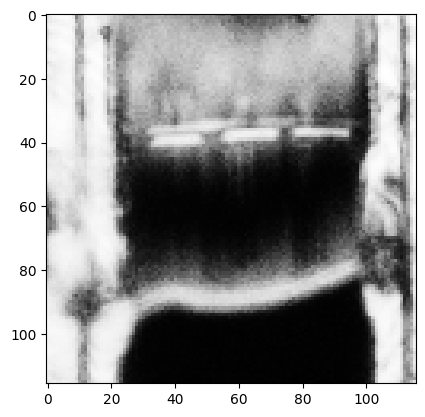

In [33]:
# now select the best tile, this would be done by selecting a point or just the tile number
best_tile_idx = 7
t_y0, t_x0, t_y1, t_x1 = tiles_bbox[best_tile_idx]
best_tile = padded[t_y0:t_y1, t_x0:t_x1]
plt.imshow(best_tile)

In [34]:
img_arr = [best_tile]
swinir_model = load_swinir_model()
upscaled = swinir_upscale( # upscaled is a list
    swinir_model,
    img_arr,
)

c:\Users\sar31\Documents\GitHub\flm_tem_alignment\.venv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\sar31\Documents\GitHub\flm_tem_alignment\.venv\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ SwinIR loaded from 002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth


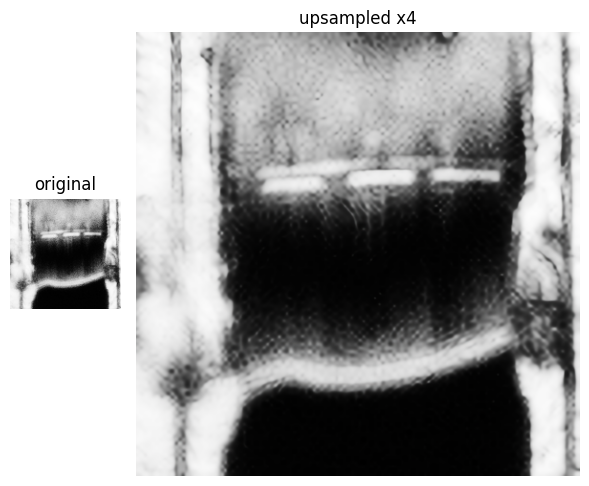

In [35]:
upscaled_best_tile = upscaled[0]
h1, w1 = best_tile.shape[:2]
h2, w2 = upscaled_best_tile.shape[:2]

# use widths proportional to pixel widths; height will auto-scale to fit figure
width_ratios = [w1, w2]

fig = plt.figure(figsize=(6, max(4, 6 * max(h1/w1, h2/w2))))
gs = GridSpec(1, 2, width_ratios=width_ratios, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(best_tile, cmap='gray' if best_tile.ndim==2 else None)
ax0.set_title('original')
ax0.axis('off')

ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(upscaled_best_tile, cmap='gray' if upscaled_best_tile.ndim==2 else None)
ax1.set_title('upsampled x4')
ax1.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# now the next step is thresholding

img = upscaled_best_tile[:, :, 0] # select any one channel
def show_threshold(thresh):
    fig, ax = plt.subplots(figsize=(4, 4))
    thresh_img = (img > thresh).astype(np.uint8) * 255
    ax.imshow(thresh_img, cmap='gray')
    ax.set_title(f'Threshold: {thresh}')
    plt.show()

slider = widgets.IntSlider(
    min=int(img.min()),
    max=int(img.max()),
    step=int((img.max() - img.min()) / 100),
    value=int(img.max() * 0.5),
    description='Threshold'
)

widgets.interact(show_threshold, thresh=slider);

interactive(children=(IntSlider(value=127, description='Threshold', max=254, step=2), Output()), _dom_classes=…

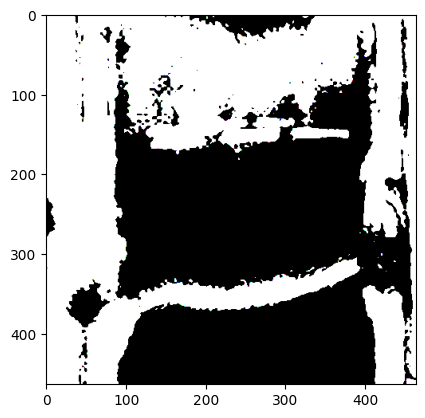

In [37]:
# the next step set the threshold and then segment the image
upscaled_tile_thresh = 150
upscaled_thresh_tile = (upscaled_best_tile > upscaled_tile_thresh).astype(np.uint8) * 255
plt.imshow(upscaled_thresh_tile)

### Segment Anything provides general purpose segmentation without any domain specific training
![Fish Segmentation](./Picture2.png)

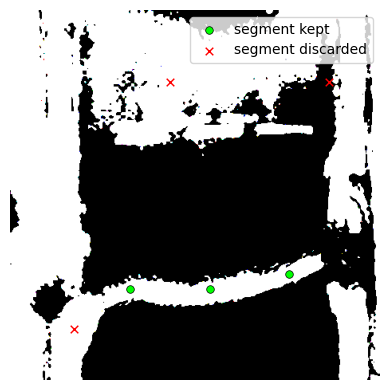

In [38]:
# add points for segmentation
green_pts = [(150, 350), (250, 350), (350, 330)] # (x, y)
red_pts   = [(80, 400), (200, 90), (400, 90)]

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(upscaled_thresh_tile, cmap='gray' if upscaled_thresh_tile.ndim==2 else None)
ax.scatter([p[0] for p in green_pts], [p[1] for p in green_pts],
           c='lime', s=30, marker='o', edgecolors='black', linewidths=0.5, label='segment kept')
ax.scatter([p[0] for p in red_pts], [p[1] for p in red_pts],
           c='red', s=30, marker='x', linewidths=1.0, label='segment discarded')
ax.axis('off')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [39]:
# load sam2 for segmentation. 
_, predictor = load_sam2_model()

✓ SAM2 loaded from sam2.1_hiera_small.pt


In [40]:
predictor.set_image(upscaled_thresh_tile)

In [41]:
coords = np.array([[x, y]  for x, y in green_pts + red_pts])
labs = np.array([1] * len(green_pts) + [0] * len(red_pts))

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        point_coords=coords,
        point_labels=labs,
        multimask_output=True
    )

flm_segmentation_mask = masks[np.argmax(scores)]
flm_segmentation_mask = flm_segmentation_mask.astype(np.uint8) * 255

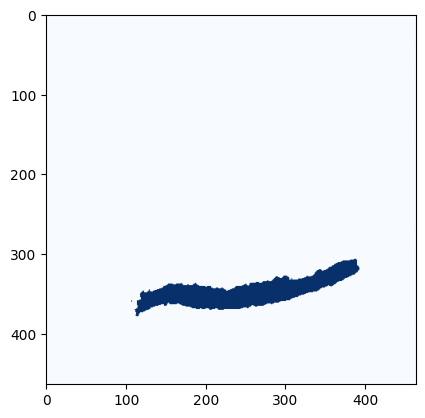

In [42]:
plt.imshow(flm_segmentation_mask, cmap='Blues')

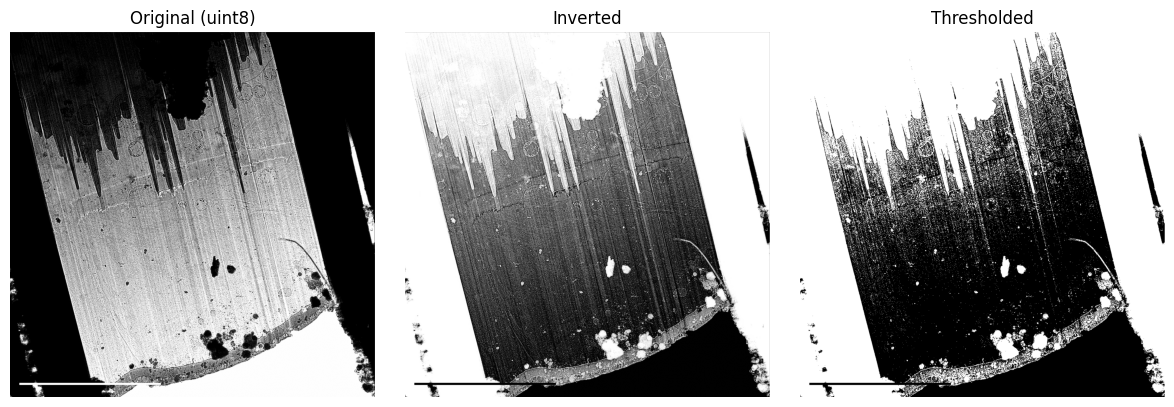

In [43]:
# assume tem_img and thresh are defined
img = tem_img.copy()
if img.ndim == 3:
    img = img[:, :, 0]

thresh = 130

# normalize to uint8
img_u8 = ((img.astype(float) - img.min()) / (img.max() - img.min() + 1e-8) * 255).astype(np.uint8)
inverted = 255 - img_u8
thresh_img = (inverted > thresh).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_u8, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (uint8)')
axes[0].axis('off')

axes[1].imshow(inverted, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Inverted')
axes[1].axis('off')

axes[2].imshow(thresh_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Thresholded')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [44]:
_, tem_inv_thresh_img = prepare_tem(tem_img)

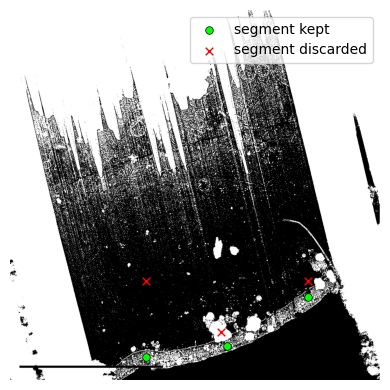

In [45]:
# segment the image 
# add points for segmentation

green_pts = [(500, 1280), (800, 1240), (1100, 1060)] # (x, y)
red_pts   = [(500, 1000), (780, 1190), (1100, 1000)]

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(tem_inv_thresh_img, cmap='gray' if tem_inv_thresh_img.ndim==2 else None)
ax.scatter([p[0] for p in green_pts], [p[1] for p in green_pts],
           c='lime', s=30, marker='o', edgecolors='black', linewidths=0.5, label='segment kept')
ax.scatter([p[0] for p in red_pts], [p[1] for p in red_pts],
           c='red', s=30, marker='x', linewidths=1.0, label='segment discarded')
ax.axis('off')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

predictor.set_image(tem_inv_thresh_img)
coords = np.array([[x, y]  for x, y in green_pts + red_pts])
labs = np.array([1] * len(green_pts) + [0] * len(red_pts))

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        point_coords=coords,
        point_labels=labs,
        multimask_output=True
    )

tem_segmentation_mask = masks[np.argmax(scores)]
tem_segmentation_mask = tem_segmentation_mask.astype(np.uint8) * 255

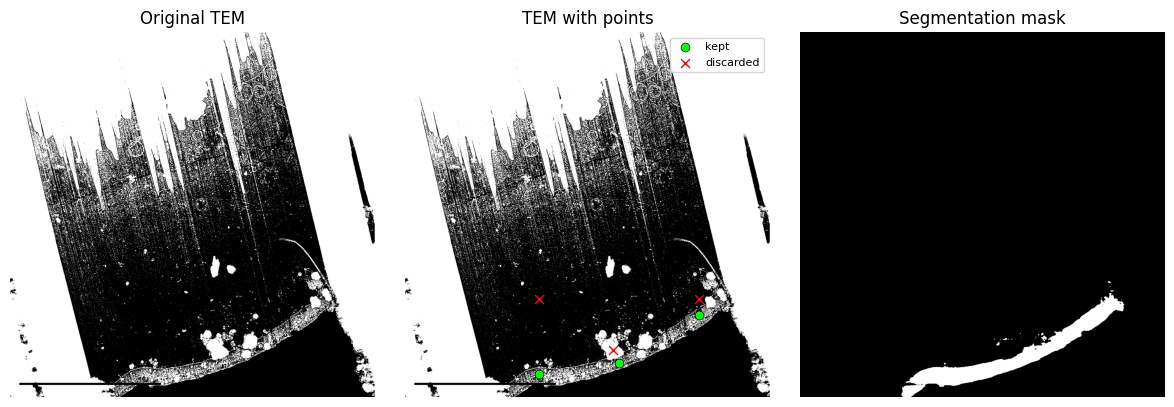

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) Original
ax = axes[0]
ax.imshow(tem_inv_thresh_img, cmap='gray' if tem_inv_thresh_img.ndim==2 else None)
ax.set_title('Original TEM')
ax.axis('off')

# 2) TEM with points
ax = axes[1]
ax.imshow(tem_inv_thresh_img, cmap='gray' if tem_inv_thresh_img.ndim==2 else None)
gx = [p[0] for p in green_pts]; gy = [p[1] for p in green_pts]
rx = [p[0] for p in red_pts];   ry = [p[1] for p in red_pts]
ax.scatter(gx, gy, c='lime', s=40, marker='o', edgecolors='black', linewidths=0.5, label='kept')
ax.scatter(rx, ry, c='red',  s=40, marker='x', linewidths=1.0, label='discarded')
ax.set_title('TEM with points')
ax.axis('off')
ax.legend(loc='upper right', fontsize=8)

# 3) Segmentation mask (and overlay)
ax = axes[2]
ax.imshow(tem_segmentation_mask, cmap='gray', vmin=0, vmax=255)
ax.set_title('Segmentation mask')
ax.axis('off')

plt.tight_layout()
plt.show()

### LightGlue and SuperPoint find and match corresponding keypoints across boundaries
![Point Matches](./Picture3.png)

In [47]:
# now finally derive the keypoints. 
extractor, matcher = load_lightglue_models()

✓ SuperPoint + LightGlue loaded


In [48]:
thresh = 0.02
device = "cuda" if torch.cuda.is_available() else "cpu"

t0 = create_tensor_from_mask(flm_segmentation_mask / 255.0, device)
t1t = create_tensor_from_mask(tem_segmentation_mask / 255.0, device)

_, _, mk0, mk1, m01 = get_keypoint_matches(extractor, matcher, t0, t1t, thresh)

mk0 = mk0.cpu().numpy()
mk1 = mk1.cpu().numpy()

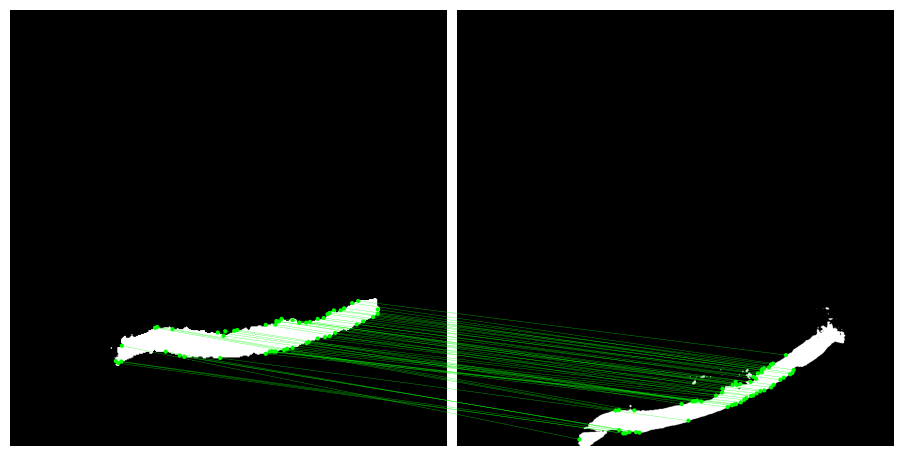

In [49]:
viz2d.plot_images([t0[0][0], t1t[0][0]])
viz2d.plot_matches(mk0, mk1, color="lime", lw=0.2)

In [50]:
# estimate transform
M, _, scale = estimate_transform(mk0, mk1)

# first the transform on upsampled image and tem
ti = tem_segmentation_mask
fi = flm_segmentation_mask
if ti.ndim == 3:
    ti = cv2.cvtColor(ti, cv2.COLOR_BGR2GRAY)
if fi.ndim == 3:
    fi = cv2.cvtColor(fi, cv2.COLOR_BGR2GRAY)
overlay, _, _, _ = apply_transform_overlay(fi, ti, M)

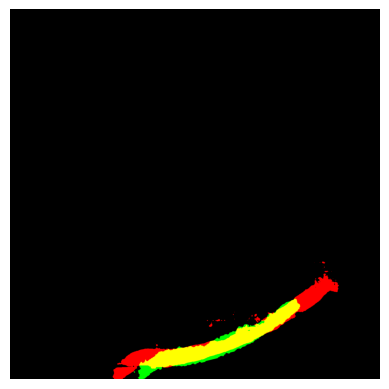

In [51]:
plt.imshow(overlay)
plt.axis('off');

In [52]:
# transform the keypoints on the flm upscaled image to the original image
full_mk0 = mk0 / 4 # images are upscaled 4x
full_mk0[:, 0] += bb_x0 + t_x0
full_mk0[:, 1] += bb_y0 + t_y0

# estimate transform
M, _, scale = estimate_transform(full_mk0, mk1)


# first the transform on upsampled image and tem
ti = 255 - tem_img
fi = flm_refl_uint8
if ti.ndim == 3:
    ti = cv2.cvtColor(ti, cv2.COLOR_BGR2GRAY)
if fi.ndim == 3:
    fi = cv2.cvtColor(fi, cv2.COLOR_BGR2GRAY)
overlay_full, _, _, _ = apply_transform_overlay(fi, ti, M)

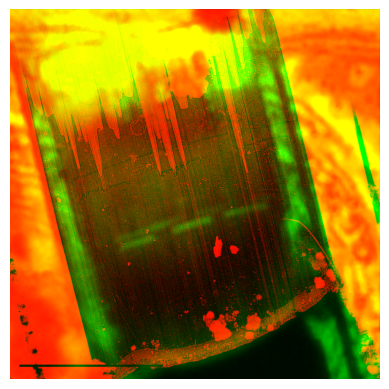

In [53]:
plt.imshow(overlay_full)
plt.axis('off');